# Bloque 3 — Manejo y preprocesamiento de datos
### Curso: Digitalización en Acuicultura

---

Este notebook muestra, paso a paso, cómo tratar una serie temporal de datos de sensor antes de analizarla.

Trabajaremos con una serie sintética de **oxígeno disuelto (mg/L)** medido cada 5 minutos durante 24 horas.  
La serie incluye, de forma controlada, los tres problemas más habituales en datos reales:

1. **Datos erróneos** — valores fuera del rango físico posible
2. **Outliers** — valores anómalos pero dentro del rango
3. **Huecos** — periodos sin datos por fallo del sensor

Librerías necesarias: `pandas`, `numpy`, `matplotlib`.  
No es necesario saber programar para seguir el notebook — cada celda incluye una explicación de qué se hace y por qué.


In [5]:
!pip install pandas numpy matplotlib

## Sección 0 — Importar librerías

Cargamos las tres librerías que usaremos a lo largo del notebook.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Estilo de gráficos
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['lines.linewidth'] = 1.5


## Sección 1 — Generación y visualización de datos en bruto

Generamos una serie temporal de oxígeno disuelto con las siguientes características:
- **Frecuencia**: una lectura cada 5 minutos durante 24 horas (288 puntos)
- **Patrón real**: el O₂ baja por la noche (sin fotosíntesis) y sube durante el día
- **Ruido**: pequeñas fluctuaciones aleatorias, normales en cualquier sensor
- **Problemas introducidos**: datos erróneos, outliers y huecos

Esta es la serie tal y como saldría del sensor — sin ningún tratamiento.


In [7]:
np.random.seed(42)

# Índice temporal: cada 5 minutos durante 24 horas
timestamps = pd.date_range("2024-01-15 00:00", periods=288, freq="5min")

# Patrón base de O2: curva sinusoidal (mínimo nocturno, máximo diurno)
horas = np.linspace(0, 24, 288)
o2_base = 8.5 + 1.5 * np.sin((horas - 6) / 24 * 2 * np.pi)

# Añadir ruido gaussiano
ruido = np.random.normal(0, 0.15, 288)
o2 = o2_base + ruido

# --- Introducir problemas ---

# 1. Datos erróneos: valores físicamente imposibles (O2 negativo)
o2[45] = -3.2
o2[46] = -1.8

# 2. Outliers: picos anómalos dentro del rango pero muy alejados de la tendencia
o2[120] = 14.5
o2[200] = 1.2

# 3. Huecos: el sensor deja de enviar datos durante 30 minutos
o2[160:166] = np.nan

# Crear DataFrame
df = pd.DataFrame({"timestamp": timestamps, "o2_mgL": o2})
df = df.set_index("timestamp")

print(f"Total de puntos: {len(df)}")
print(f"Puntos con dato faltante (NaN): {df['o2_mgL'].isna().sum()}")
print(f"Rango de valores: {df['o2_mgL'].min():.2f} – {df['o2_mgL'].max():.2f} mg/L")
print()
print(df.head(10))


Total de puntos: 288
Puntos con dato faltante (NaN): 6
Rango de valores: -3.20 – 14.50 mg/L

                       o2_mgL
timestamp                    
2024-01-15 00:00:00  7.074507
2024-01-15 00:05:00  6.979620
2024-01-15 00:10:00  7.098591
2024-01-15 00:15:00  7.231689
2024-01-15 00:20:00  6.970625
2024-01-15 00:25:00  6.973857
2024-01-15 00:30:00  7.249804
2024-01-15 00:35:00  7.132695
2024-01-15 00:40:00  6.952526
2024-01-15 00:45:00  7.110407


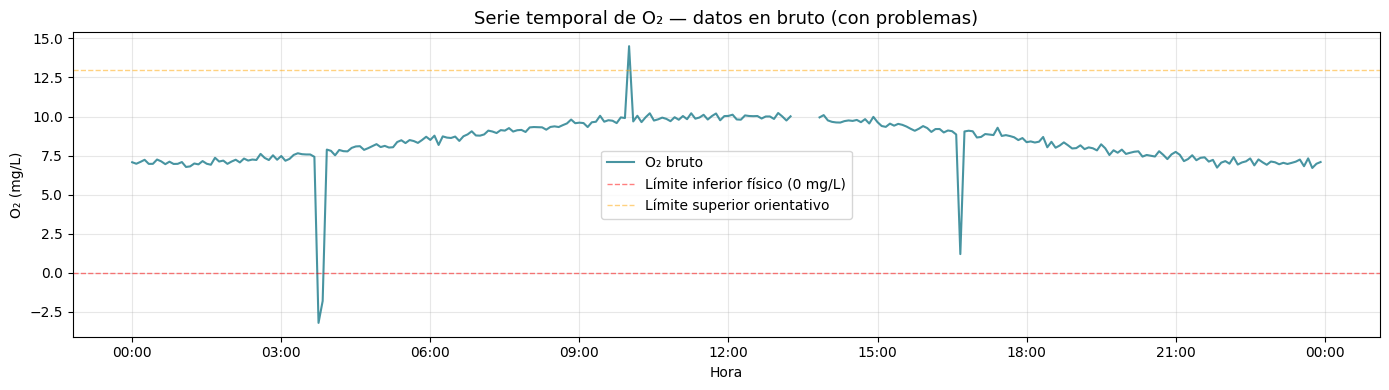

In [8]:
# Visualización de la serie en bruto
fig, ax = plt.subplots()
ax.plot(df.index, df['o2_mgL'], color='#1A7A8A', alpha=0.8, label='O₂ bruto')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Límite inferior físico (0 mg/L)')
ax.axhline(13, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Límite superior orientativo')
ax.set_title('Serie temporal de O₂ — datos en bruto (con problemas)', fontsize=13)
ax.set_ylabel('O₂ (mg/L)')
ax.set_xlabel('Hora')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()


## Sección 2 — Limpieza de datos erróneos

El primer paso es eliminar los valores que son **físicamente imposibles**.

Para el oxígeno disuelto en agua, los límites físicos son claros:
- **Mínimo**: 0 mg/L (agua completamente anóxica)
- **Máximo**: ~20 mg/L (saturación máxima en agua fría)

Cualquier valor fuera de este rango no puede ser real — es un error del sensor o de transmisión.  
Lo marcamos como `NaN` para que los pasos posteriores lo traten como dato faltante.


In [9]:
df_limpio = df.copy()

# Definir límites físicos del oxígeno disuelto
O2_MIN = 0.0   # mg/L
O2_MAX = 20.0  # mg/L

# Contar errores antes de limpiar
errores = ((df_limpio['o2_mgL'] < O2_MIN) | (df_limpio['o2_mgL'] > O2_MAX)).sum()
print(f"Valores fuera de rango físico detectados: {errores}")

# Sustituir por NaN
df_limpio['o2_mgL'] = df_limpio['o2_mgL'].where(
    (df_limpio['o2_mgL'] >= O2_MIN) & (df_limpio['o2_mgL'] <= O2_MAX)
)

print(f"NaN tras limpieza: {df_limpio['o2_mgL'].isna().sum()}")


Valores fuera de rango físico detectados: 2
NaN tras limpieza: 8


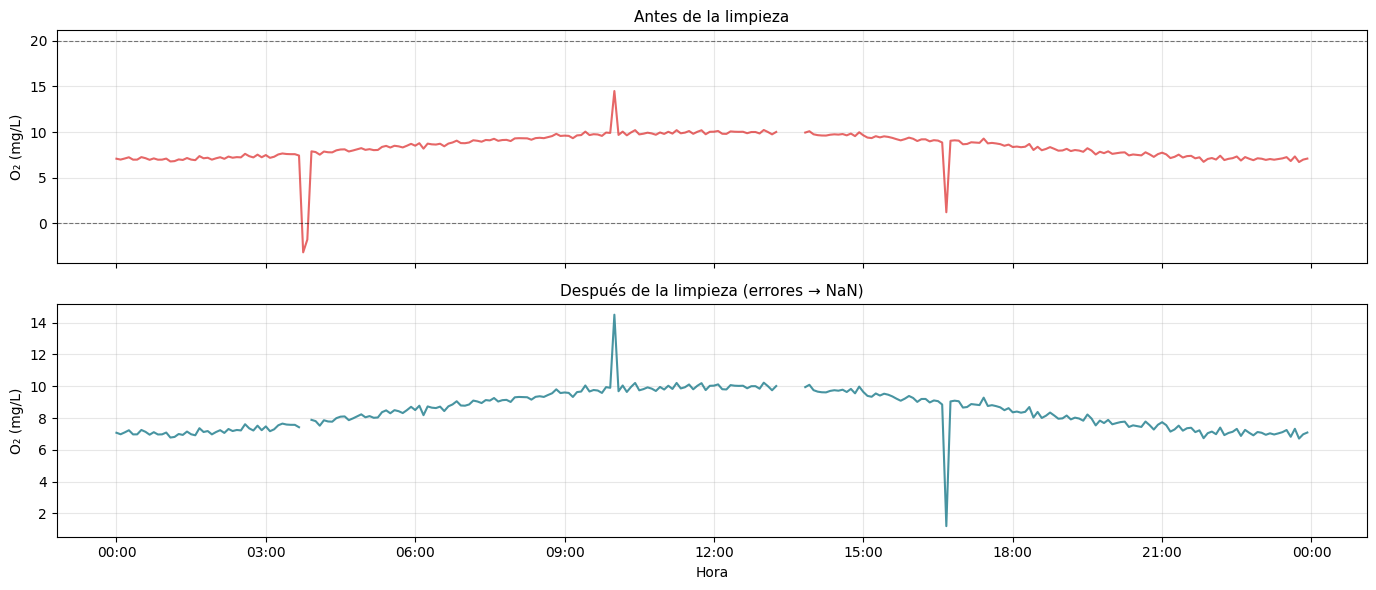

In [10]:
# Visualización: antes y después de la limpieza
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df.index, df['o2_mgL'], color='#DC2626', alpha=0.7)
axes[0].set_title('Antes de la limpieza', fontsize=11)
axes[0].set_ylabel('O₂ (mg/L)')
axes[0].axhline(O2_MIN, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(O2_MAX, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

axes[1].plot(df_limpio.index, df_limpio['o2_mgL'], color='#1A7A8A', alpha=0.8)
axes[1].set_title('Después de la limpieza (errores → NaN)', fontsize=11)
axes[1].set_ylabel('O₂ (mg/L)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].set_xlabel('Hora')

plt.tight_layout()
plt.show()


## Sección 3 — Detección de outliers

Los **outliers** son valores que, aunque estén dentro del rango físico posible, se alejan significativamente del comportamiento normal de la serie.

Usaremos el método del **rango intercuartílico (IQR)**:
- Calculamos el primer cuartil (Q1) y el tercero (Q3)
- El rango intercuartílico es IQR = Q3 - Q1
- Consideramos outlier cualquier valor que esté a más de **2.5 × IQR** por encima de Q3 o por debajo de Q1

Este método es robusto y no asume que los datos siguen una distribución normal.

> ⚠️ Importante: un outlier detectado no siempre es un error. Puede ser un evento real (un fallo de aireación, por ejemplo). Siempre hay que interpretarlo con criterio antes de eliminarlo.


In [11]:
# Calcular IQR sobre los valores no nulos
Q1 = df_limpio['o2_mgL'].quantile(0.25)
Q3 = df_limpio['o2_mgL'].quantile(0.75)
IQR = Q3 - Q1

factor = 2.5
limite_inferior = Q1 - factor * IQR
limite_superior = Q3 + factor * IQR

print(f"Q1: {Q1:.2f} mg/L")
print(f"Q3: {Q3:.2f} mg/L")
print(f"IQR: {IQR:.2f} mg/L")
print(f"Límite inferior outlier: {limite_inferior:.2f} mg/L")
print(f"Límite superior outlier: {limite_superior:.2f} mg/L")

# Detectar outliers
outliers = (df_limpio['o2_mgL'] < limite_inferior) | (df_limpio['o2_mgL'] > limite_superior)
print(f"\nOutliers detectados: {outliers.sum()}")
print(df_limpio[outliers])


Q1: 7.40 mg/L
Q3: 9.53 mg/L
IQR: 2.14 mg/L
Límite inferior outlier: 2.06 mg/L
Límite superior outlier: 14.87 mg/L

Outliers detectados: 1
                     o2_mgL
timestamp                  
2024-01-15 16:40:00     1.2


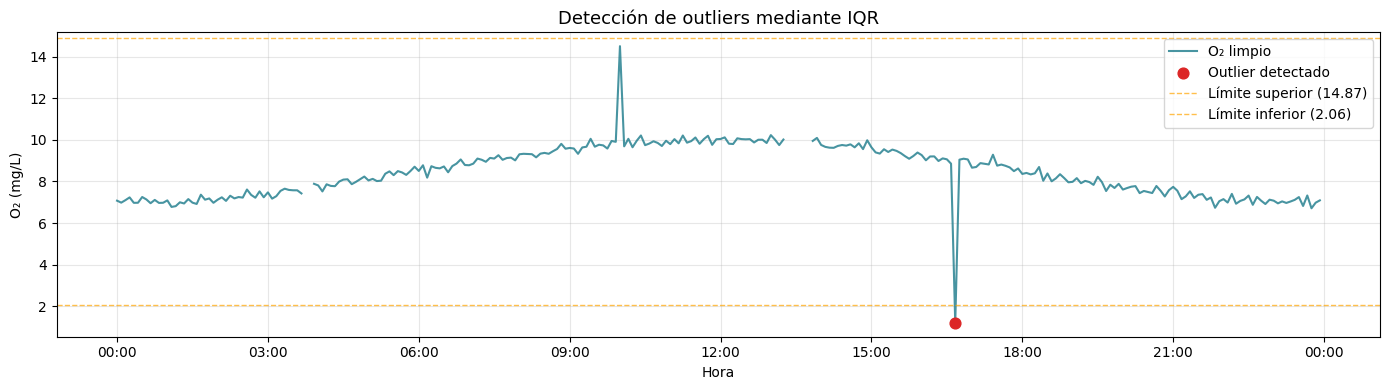

NaN tras eliminar outliers: 9


In [12]:
# Visualización de outliers
fig, ax = plt.subplots()
ax.plot(df_limpio.index, df_limpio['o2_mgL'], color='#1A7A8A', alpha=0.8, label='O₂ limpio')
ax.scatter(df_limpio.index[outliers], df_limpio['o2_mgL'][outliers],
           color='#DC2626', zorder=5, s=60, label='Outlier detectado')
ax.axhline(limite_superior, color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'Límite superior ({limite_superior:.2f})')
ax.axhline(limite_inferior, color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'Límite inferior ({limite_inferior:.2f})')
ax.set_title('Detección de outliers mediante IQR', fontsize=13)
ax.set_ylabel('O₂ (mg/L)')
ax.set_xlabel('Hora')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()

# Eliminar outliers (marcar como NaN)
df_limpio['o2_mgL'] = df_limpio['o2_mgL'].where(~outliers)
print(f"NaN tras eliminar outliers: {df_limpio['o2_mgL'].isna().sum()}")


## Sección 4 — Interpolación de huecos

Ahora tenemos varios valores `NaN` en la serie: los errores físicos, los outliers y los huecos originales del sensor.

La **interpolación lineal** estima el valor de cada punto faltante trazando una línea recta entre el último valor válido antes del hueco y el primero después.

Es el método más sencillo y funciona bien cuando los huecos son cortos y la serie no cambia bruscamente.  
Para huecos largos o series muy irregulares, existen métodos más sofisticados (splines, interpolación estacional, etc.).


In [13]:
df_interpolado = df_limpio.copy()

# Número de NaN antes
nan_antes = df_interpolado['o2_mgL'].isna().sum()
print(f"NaN antes de interpolar: {nan_antes}")

# Interpolación lineal
df_interpolado['o2_mgL'] = df_interpolado['o2_mgL'].interpolate(method='linear')

nan_despues = df_interpolado['o2_mgL'].isna().sum()
print(f"NaN después de interpolar: {nan_despues}")


NaN antes de interpolar: 9
NaN después de interpolar: 0


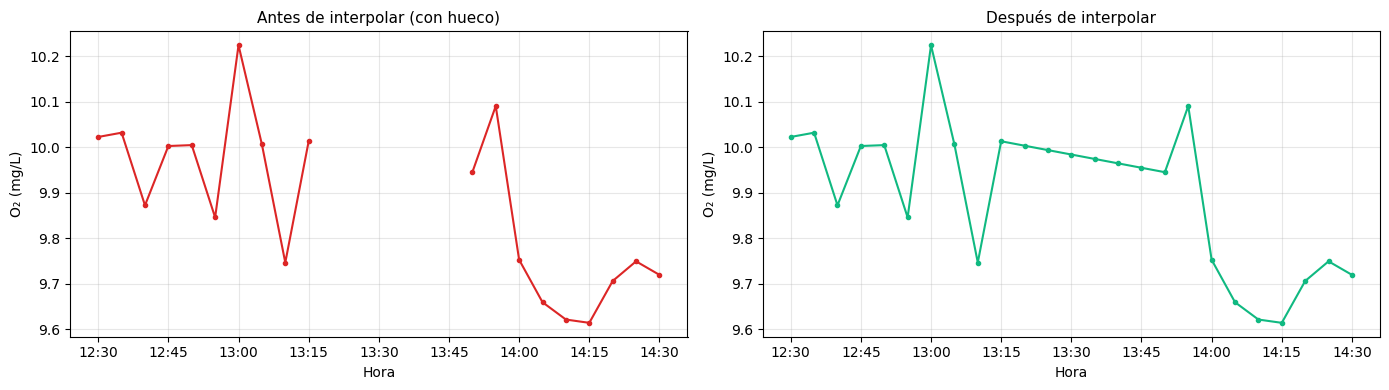

In [14]:
# Visualización: hueco antes y después de la interpolación
# Zoom en la zona del hueco (alrededor de las 13:20)
inicio = pd.Timestamp("2024-01-15 12:30")
fin    = pd.Timestamp("2024-01-15 14:30")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df_plot, titulo, color in zip(
    axes,
    [df_limpio, df_interpolado],
    ['Antes de interpolar (con hueco)', 'Después de interpolar'],
    ['#DC2626', '#10B981']
):
    mascara = (df_plot.index >= inicio) & (df_plot.index <= fin)
    ax.plot(df_plot.index[mascara], df_plot['o2_mgL'][mascara], color=color, marker='o', markersize=3)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('O₂ (mg/L)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel('Hora')

plt.tight_layout()
plt.show()


## Sección 5 — Filtrado de ruido (media móvil)

Incluso después de limpiar e interpolar, la serie todavía tiene **ruido**: pequeñas fluctuaciones aleatorias que no reflejan cambios reales en el agua, sino la variabilidad natural del sensor.

La **media móvil** suaviza la serie calculando, para cada punto, la media de los N puntos anteriores y posteriores.  
Cuanto mayor es N, más suave queda la curva — pero también se pierde más detalle.

Usaremos una ventana de **12 puntos** (= 60 minutos con datos cada 5 min), que es un equilibrio razonable.


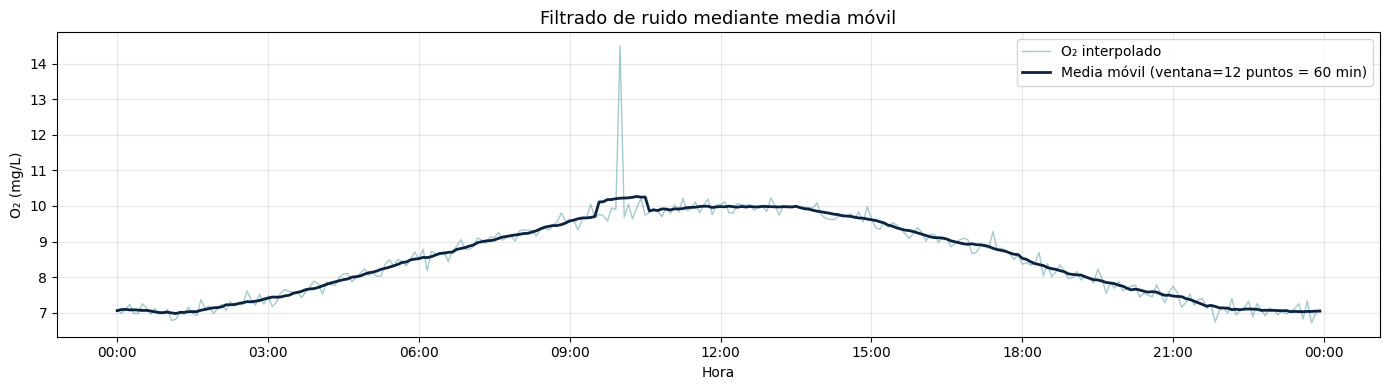

In [15]:
# Media móvil centrada con ventana de 12 puntos (60 minutos)
ventana = 12
df_interpolado['o2_suavizado'] = df_interpolado['o2_mgL'].rolling(
    window=ventana, center=True, min_periods=1
).mean()

# Visualización: serie interpolada vs. suavizada
fig, ax = plt.subplots()
ax.plot(df_interpolado.index, df_interpolado['o2_mgL'],
        color='#1A7A8A', alpha=0.4, linewidth=1, label='O₂ interpolado')
ax.plot(df_interpolado.index, df_interpolado['o2_suavizado'],
        color='#0A2342', linewidth=2, label=f'Media móvil (ventana={ventana} puntos = 60 min)')
ax.set_title('Filtrado de ruido mediante media móvil', fontsize=13)
ax.set_ylabel('O₂ (mg/L)')
ax.set_xlabel('Hora')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()


## Sección 6 — Análisis descriptivo básico

Con la serie ya limpia, interpolada y suavizada, podemos extraer los primeros estadísticos descriptivos.

Estos valores resumen el comportamiento general de la variable y sirven de punto de partida para cualquier análisis posterior.


In [16]:
serie_final = df_interpolado['o2_suavizado']

stats = {
    'Media':               serie_final.mean(),
    'Mediana':             serie_final.median(),
    'Desviación típica':   serie_final.std(),
    'Mínimo':              serie_final.min(),
    'Máximo':              serie_final.max(),
    'Rango':               serie_final.max() - serie_final.min(),
}

print("=== Estadísticos descriptivos — O₂ disuelto (mg/L) ===")
print()
for k, v in stats.items():
    print(f"  {k:<22}: {v:.3f} mg/L")


=== Estadísticos descriptivos — O₂ disuelto (mg/L) ===

  Media                 : 8.511 mg/L
  Mediana               : 8.522 mg/L
  Desviación típica     : 1.096 mg/L
  Mínimo                : 6.971 mg/L
  Máximo                : 10.268 mg/L
  Rango                 : 3.297 mg/L


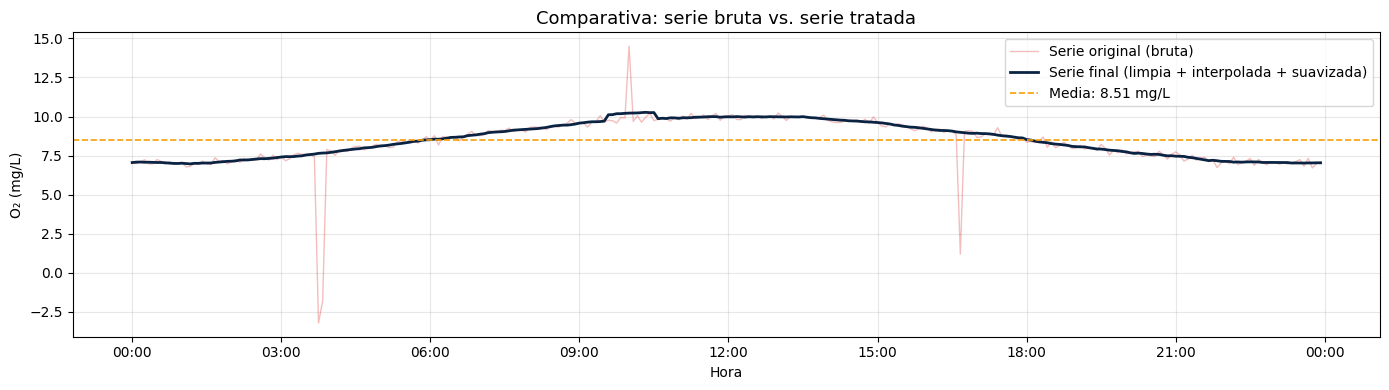

In [17]:
# Visualización final: serie completa tratada
fig, ax = plt.subplots()
ax.plot(df.index, df['o2_mgL'],
        color='#DC2626', alpha=0.3, linewidth=1, label='Serie original (bruta)')
ax.plot(df_interpolado.index, df_interpolado['o2_suavizado'],
        color='#0A2342', linewidth=2, label='Serie final (limpia + interpolada + suavizada)')
ax.axhline(serie_final.mean(), color='#F59E0B', linestyle='--', linewidth=1.2,
           label=f'Media: {serie_final.mean():.2f} mg/L')
ax.set_title('Comparativa: serie bruta vs. serie tratada', fontsize=13)
ax.set_ylabel('O₂ (mg/L)')
ax.set_xlabel('Hora')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()


---

## Resumen del proceso

| Paso | Qué se hizo | Resultado |
|---|---|---|
| **Limpieza** | Eliminación de valores fuera de rango físico | 2 errores detectados y marcados como NaN |
| **Outliers** | Detección mediante IQR (factor 2.5) | 2 outliers detectados y eliminados |
| **Interpolación** | Relleno lineal de todos los NaN | 0 huecos restantes |
| **Suavizado** | Media móvil de 60 minutos | Ruido reducido, tendencia visible |

> La serie que sale de este proceso es la que se usará en los bloques siguientes para el análisis y la construcción de modelos predictivos.
